# Getting started with MOOGP

`moogp` emulates vector-valued (multi-output) functions with a **multi-output
orthogonal Gaussian process**. It models the `p` outputs as a linear
combination of `q` shared latent GPs, plus a regression trend `g(x)` that the
latent kernels are orthogonalized against.

This notebook walks through the full workflow on a toy problem
(the Forrester functions):

1. Generate noisy training data.
2. Construct a `MOOGP` model.
3. Fit it by maximum likelihood.
4. Predict the mean and uncertainty on a dense grid.
5. Evaluate accuracy and calibration.
6. Inspect the fitted hyperparameters.

In [2]:
# !pip install moogp
# !pip install matplotlib

import numpy as np
import matplotlib.pyplot as plt

import moogp
from moogp.model import MOOGP
from moogp.datasets import generate_forrester_data
from moogp import evaluation  # optional RMSE / coverage helpers

print("moogp", moogp.__version__)

moogp 0.9.2


## 1. Generate data

`generate_forrester_data` returns a `dict` with `X` (raw inputs in `[0, 1]`),
`X_scaled` (mapped to `[-1, 1]`), `y` (noisy observations), and `f` (the
noise-free truth). With the default `standardize_x="unitcube"` the model
rescales inputs internally, so we can pass the raw `X` straight to `fit` and
`predict`.

In [53]:
n_train = 25
p = 3  # number of outputs
sigma_eps2_true = np.array([1.0, 0.5, 0.1])  # per-output noise variance

data = generate_forrester_data(
    n=n_train,
    seed=123,
    with_error=True,
    error_per_output=sigma_eps2_true,
)
X_train = data["X"]   # (n, 1) on [0, 1]
Y_train = data["y"]   # (n, p) noisy observations
F_train = data["f"]   # (n, p) noise-free truth
print("X_train:", X_train.shape, "  Y_train:", Y_train.shape)

X_train: (25, 1)   Y_train: (25, 3)


Let's plot the generated training data over the true Forrester functions (see [here](https://www.sfu.ca/~ssurjano/forretal08.html) for more details on the Forrester functions).

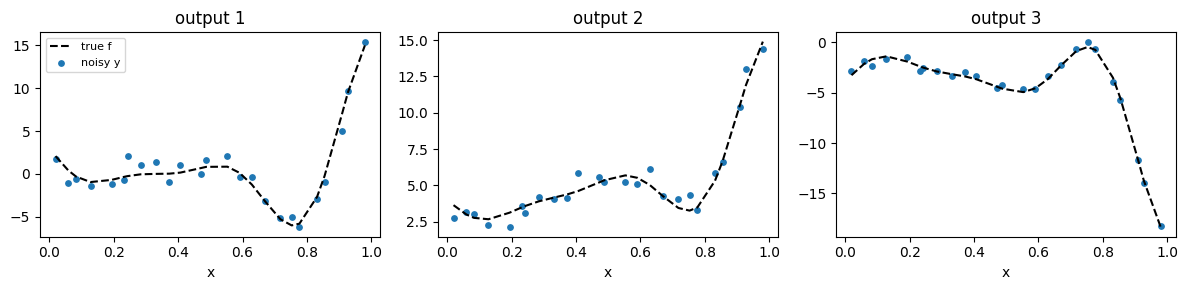

In [54]:
# Plot data points on true function
fig, axes = plt.subplots(1, p, figsize=(12, 3), sharex=True)
order = np.argsort(X_train[:, 0])
for j, ax in enumerate(axes):
    ax.plot(X_train[order, 0], F_train[order, j], "k--", label="true f")
    ax.scatter(X_train[:, 0], Y_train[:, j], s=15, label="noisy y")
    ax.set_title(f"output {j + 1}")
    ax.set_xlabel("x")
axes[0].legend(loc="best", fontsize=8)
fig.tight_layout()

## 2. Construct the model

The most important constructor arguments:

| Argument | Here | Meaning |
| --- | --- | --- |
| `terms` | `[None, 1]` | Trend basis `g(x) = [1, x_1]` (intercept + linear). |
| `q` | `3` | Number of latent GPs (`q <= p`). |
| `orthogonal` | `True` | Orthogonalize the latent kernels against `g(x)` (the core MOOGP idea). |
| `learn_sigma_eps` | `True` | Learn the per-output measurement-noise variance. |


In [55]:
model = MOOGP(
    terms=[None, 1],      # intercept + linear trend in x
    q=p,                  # full-rank coupling between outputs
    orthogonal=True,
    learn_sigma_eps=True,
)
model

## 3. Fit

`fit` minimizes the negative log-likelihood with L-BFGS-B.

In [56]:
model.fit(data)
print("converged:", model.opt_result.success, "  NLL:", round(model.nll_hat, 4))

converged: False   NLL: -0.4597


## 4. Predict

`predict` returns the posterior mean of shape `(n_star, p)` and, with
`return_std=True`, the per-output predictive standard deviation. 

> **Note**: Predictions are
always returned on the original output scale.

In [40]:
X_star = np.linspace(0, 1, 200).reshape(-1, 1)
Y_mean, Y_std = model.predict(X_star, return_std=True)
Y_mean.shape, Y_std.shape

((200, 3), (200, 3))

We plot the posterior mean and plus or minus two times the standard deviation as the uncertainty interval on all three outputs.

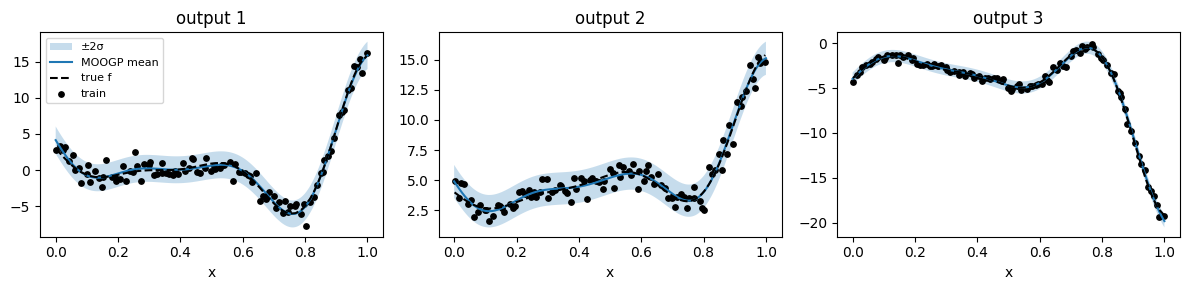

In [41]:
fig, axes = plt.subplots(1, p, figsize=(12, 3), sharex=True)
order = np.argsort(X_train[:, 0])
for j, ax in enumerate(axes):
    x = X_star[:, 0]
    ax.fill_between(x, Y_mean[:, j] - 2 * Y_std[:, j], Y_mean[:, j] + 2 * Y_std[:, j],
                    alpha=0.25, label="±2σ")
    ax.plot(x, Y_mean[:, j], label="MOOGP mean")
    ax.plot(X_train[order, 0], F_train[order, j], "k--", label="true f")
    ax.scatter(X_train[:, 0], Y_train[:, j], s=15, c="k", label="train")
    ax.set_title(f"output {j + 1}")
    ax.set_xlabel("x")
axes[0].legend(loc="best", fontsize=8)
fig.tight_layout()

## 5. Evaluate

The optional `moogp.evaluation` module provides standard metrics. We compare the
predicted mean to the noise-free truth on a dense grid: RMSE measures
accuracy and the 95% interval coverage measures calibration (it should land
near 0.95).

In [ ]:
test = generate_forrester_data(n=400, seed=67, with_error=True,
                               error_per_output=sigma_eps2_true,
                               X_override=np.linspace(0,1,400).reshape(-1,1))

mean, std = model.predict(test["X"], return_std=True)
rmse = evaluation.rmse(test["f"], mean)                  # accuracy still vs truth f
coverage, _ = evaluation.intervalstats(test["y"], mean, std**2)  # coverage vs noisy y

print(f"RMSE (vs true f):      {rmse:.4f}")
print(f"95% coverage:          {coverage:.3f}")

RMSE (vs true f):      0.1829
95% coverage:          0.932


## 6. Inspect fitted hyperparameters

After `fit`, `model.cache` holds the unpacked hyperparameters. The most useful
entries:

  * `lat_params` — list of `(sigma2_j, ell_j)` for each latent GP.
  * `sigma_eps2_raw` — fitted per-output noise variances on the original scale.
  * `Psi` — the fitted `p x q` mixing matrix.
  * `bhat` — the fitted trend coefficients (one column per output).

In [51]:
for j, (sigma2_j, ell_j) in enumerate(model.cache["lat_params"]):
    print(f"latent GP {j}: sigma2={sigma2_j:8.3f}  ell={np.round(ell_j, 3)}")
print()
print("fitted sigma_eps2 (raw scale):", np.round(model.cache["sigma_eps2_raw"], 3))
print("true sigma_eps2:              ", sigma_eps2_true)

latent GP 0: sigma2=2103.063  ell=[0.444]
latent GP 1: sigma2= 100.693  ell=[100.]
latent GP 2: sigma2=   4.701  ell=[0.479]

fitted sigma_eps2 (raw scale): [0.842 0.427 0.108]
true sigma_eps2:               [1.  0.5 0.1]


## Where to go from here

Each advanced feature from the README has a dedicated notebook:

  * [`01_trend_specification.ipynb`](../01_trend_specification) — choosing the
    trend basis `g(x)` with `terms` (intercepts, main effects, interactions).
  * [`02_choosing_q.ipynb`](02_choosing_q.ipynb) — picking the number of latent
    GPs `q` from the singular-value spectrum of `Y`.
  * [`03_measurement_noise.ipynb`](03_measurement_noise.ipynb) — fixed vs learned
    noise and grouping outputs with `diag_error_structure`.
  * [`04_standardization.ipynb`](04_standardization.ipynb) — `standardize_x` /
    `standardize_y` and when to disable them.
  * [`05_optimizer_control.ipynb`](05_optimizer_control.ipynb) — `optimizer_opts`
    (`maxiter`, `ftol`, `gtol`) and reading the optimizer result.
  * [`06_kernel_and_mixing_matrix.ipynb`](06_kernel_and_mixing_matrix.ipynb) —
    the `orthogonal` kernel and fixing/learning the mixing matrix `Psi`.